# COVID-19 Case Prediction with Prophet

**Objective**: Forecast daily COVID-19 cases for the next 4 weeks to support healthcare planning.

**Author**: Ibrahim Ahmed Mohammed  
**Course**: DATA610  
**Dataset**: Johns Hopkins University COVID-19 Time Series (Jan 2020 - March 2023)

**Forecasting Challenge**: Predict the **Omicron surge** (Jan 2022) - training on historical data and forecasting a major outbreak.

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from utils import (
    load_jhu_timeseries, get_available_countries,
    create_intervention_dataframe, get_us_covid_interventions,
    get_country_interventions, summarize_data,
    ProphetWrapper,
    fit_arima, fit_sarima, forecast_arima,
    calculate_rmse, calculate_mae, calculate_smape,
    evaluate_forecast, compare_models,
    plot_forecast, plot_components, plot_intervention_effects,
    plot_model_comparison
)

print("All imports successful!")

2025-12-14 10:34:14 - prophet.plot - ERROR - Importing plotly failed. Interactive plots will not work.
2025-12-14 10:34:15.902342: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-14 10:34:15.902672: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-14 10:34:15.957771: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


All imports successful!


2025-12-14 10:34:17.372152: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-14 10:34:17.372607: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 2. Data Preparation

In [2]:
# Load US COVID-19 data from Johns Hopkins
DATA_PATH = '/app/jhu_confirmed_global.csv'

prophet_df = load_jhu_timeseries(DATA_PATH, country='US')

print(f"Dataset shape: {prophet_df.shape}")
print(f"Date range: {prophet_df['ds'].min().date()} to {prophet_df['ds'].max().date()}")
print(f"Total days: {len(prophet_df)}")
prophet_df.head()

2025-12-14 10:34:17 - utils - INFO - Loading JHU time series data for US
2025-12-14 10:34:17 - utils - INFO - Successfully loaded 1143 days of data for US: 2020-01-22 to 2023-03-09


Dataset shape: (1143, 2)
Date range: 2020-01-22 to 2023-03-09
Total days: 1143


,ds,y
0,2020-01-22,0.0
1,2020-01-23,0.0
2,2020-01-24,1.0
3,2020-01-25,0.0
4,2020-01-26,3.0


In [3]:
# Data summary
summary = summarize_data(prophet_df)
print("Data Summary:")
for key, value in summary.items():
    if isinstance(value, float):
        print(f"  {key}: {value:,.2f}")
    else:
        print(f"  {key}: {value}")

2025-12-14 10:34:17 - utils - INFO - Generating data summary statistics
2025-12-14 10:34:17 - utils - INFO - Data summary: 1143 observations from 2020-01-22 to 2023-03-09


Data Summary:
  start_date: 2020-01-22 00:00:00
  end_date: 2023-03-09 00:00:00
  n_observations: 1143
  mean: 90,819.39
  std: 126,544.55
  min: 0.00
  max: 1,354,505.00
  missing_values: 0


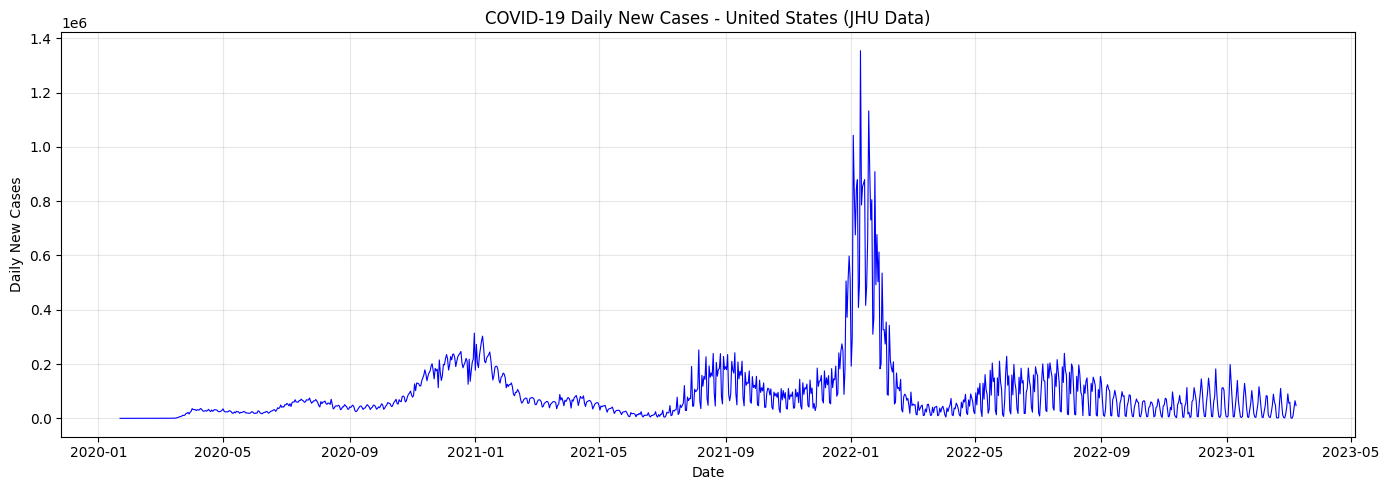

In [4]:
# Visualize raw time series
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(prophet_df['ds'], prophet_df['y'], 'b-', linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Daily New Cases')
ax.set_title('COVID-19 Daily New Cases - United States (JHU Data)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Define Interventions

In [5]:
# Get US intervention dates
interventions = get_us_covid_interventions()
print("US COVID-19 Interventions:")
for name, date in interventions.items():
    print(f"  {name}: {date}")

# Convert to Prophet holidays format
holidays_df = create_intervention_dataframe(interventions)
holidays_df

2025-12-14 10:34:17 - utils - INFO - Creating intervention dataframe with 9 events


US COVID-19 Interventions:
  national_emergency: 2020-03-13
  lockdowns_begin: 2020-03-19
  reopening_phase1: 2020-05-01
  summer_surge: 2020-07-01
  fall_surge: 2020-10-15
  vaccine_auth: 2020-12-11
  vaccine_rollout: 2021-01-15
  delta_surge: 2021-07-01
  omicron_surge: 2021-12-15


,holiday,ds,lower_window,upper_window
0,national_emergency,2020-03-13,0,14
1,lockdowns_begin,2020-03-19,0,14
2,reopening_phase1,2020-05-01,0,14
3,summer_surge,2020-07-01,0,14
4,fall_surge,2020-10-15,0,14
5,vaccine_auth,2020-12-11,0,14
6,vaccine_rollout,2021-01-15,0,14
7,delta_surge,2021-07-01,0,14
8,omicron_surge,2021-12-15,0,14


## 4. Train/Test Split

**Strategy**: Instead of predicting the end of the pandemic (declining cases), we predict the **Omicron surge** (Jan 2022) - a realistic forecasting challenge where cases exploded to 500k-800k/day.

In [6]:
# Define forecast horizon and cutoff date
FORECAST_HORIZON = 28  # 4 weeks
CUTOFF_DATE = '2022-01-01'  # Predict the Omicron surge!

# Split data at cutoff date
train = prophet_df[prophet_df['ds'] < CUTOFF_DATE].copy()
test = prophet_df[(prophet_df['ds'] >= CUTOFF_DATE) & 
                  (prophet_df['ds'] < pd.to_datetime(CUTOFF_DATE) + pd.Timedelta(days=FORECAST_HORIZON))].copy()

print(f"Training: {len(train)} days ({train['ds'].min().date()} to {train['ds'].max().date()})")
print(f"Testing:  {len(test)} days ({test['ds'].min().date()} to {test['ds'].max().date()})")
print(f"\n→ Predicting the OMICRON SURGE - a real forecasting challenge!")

Training: 710 days (2020-01-22 to 2021-12-31)
Testing:  28 days (2022-01-01 to 2022-01-28)

→ Predicting the OMICRON SURGE - a real forecasting challenge!


## 5. Prophet Model

In [7]:
# Initialize and fit Prophet
prophet_model = ProphetWrapper(
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05,  # Slightly regularized
    interval_width=0.95
)

prophet_model.set_holidays(holidays_df).fit(train)
print("Prophet model fitted!")

2025-12-14 10:34:18 - utils - INFO - ProphetWrapper initialized with config: {'growth': 'linear', 'weekly_seasonality': True, 'yearly_seasonality': True, 'daily_seasonality': False, 'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 10.0, 'holidays_prior_scale': 10.0, 'interval_width': 0.95}
2025-12-14 10:34:18 - utils - INFO - Floor constraint: 0.0 (predictions will be non-negative)
2025-12-14 10:34:18 - utils - INFO - Set 9 holidays/interventions
2025-12-14 10:34:18 - utils - INFO - Fitting Prophet model on 710 observations
2025-12-14 10:34:18 - cmdstanpy - INFO - Chain [1] start processing
2025-12-14 10:34:18 - cmdstanpy - INFO - Chain [1] done processing
2025-12-14 10:34:18 - utils - INFO - Prophet model fitted successfully


Prophet model fitted!


In [8]:
# Generate forecast
forecast = prophet_model.predict(periods=FORECAST_HORIZON, include_history=True)
forecast_test = forecast[forecast['ds'].isin(test['ds'])]

print(f"Forecast for test period: {len(forecast_test)} days")
print(f"Prediction range: {forecast_test['yhat'].min():,.0f} to {forecast_test['yhat'].max():,.0f}")
forecast_test[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

2025-12-14 10:34:18 - utils - INFO - Generating 28-period forecast
2025-12-14 10:34:18 - utils - WARNING - Clipping 35 negative predictions to floor=0.0
2025-12-14 10:34:18 - utils - INFO - Forecast generated: 738 rows (min yhat: 0.00, max yhat: 511120.13)


Forecast for test period: 28 days
Prediction range: 73,053 to 259,903


,ds,yhat,yhat_lower,yhat_upper
710,2022-01-01,248546.902850,179200.860958,319618.373622
711,2022-01-02,233172.203488,162990.996087,301181.161700
712,2022-01-03,259903.437449,194415.674851,324942.808150
713,2022-01-04,253058.931545,188707.593282,323902.768396
714,2022-01-05,253820.756206,189020.591392,314778.448383


2025-12-14 10:34:18 - utils - INFO - Creating forecast plot
2025-12-14 10:34:18 - utils - INFO - Forecast plot created


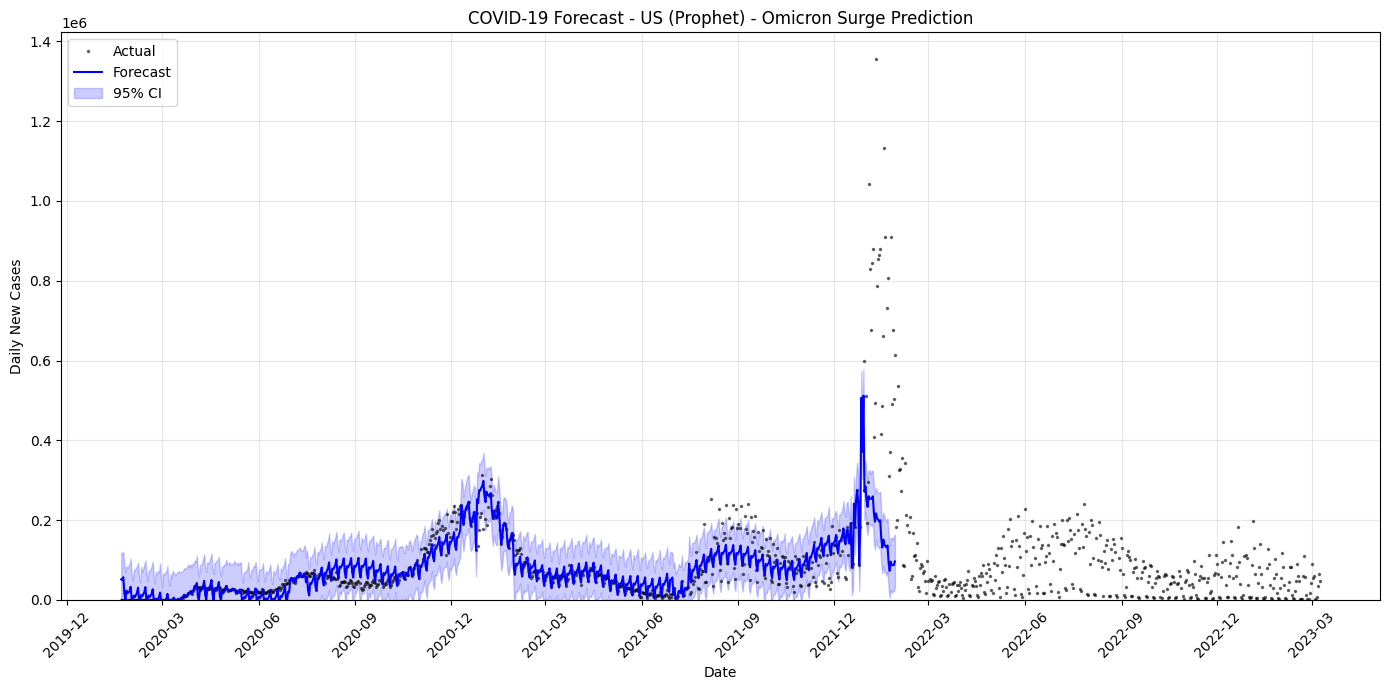

In [9]:
# Plot forecast
fig = plot_forecast(prophet_df, forecast, title='COVID-19 Forecast - US (Prophet) - Omicron Surge Prediction')
plt.show()

2025-12-14 10:34:18 - utils - INFO - Creating intervention effects plot
2025-12-14 10:34:18 - utils - INFO - Intervention effects plot created


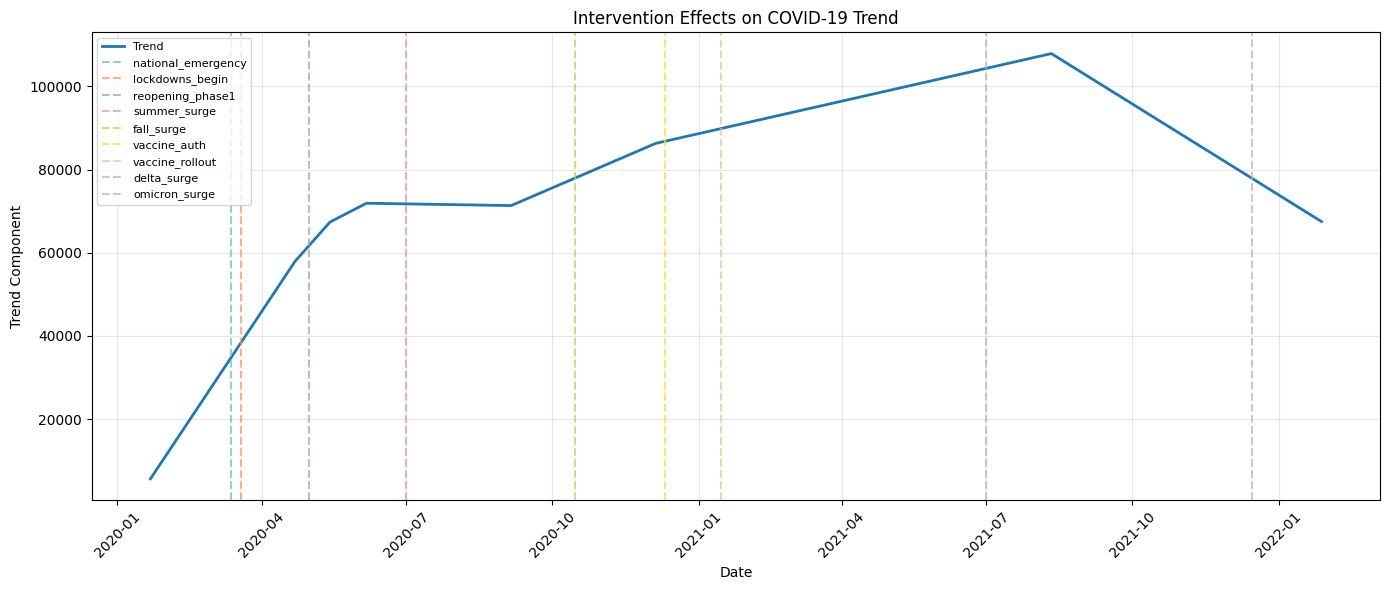

In [10]:
# Plot intervention effects
fig = plot_intervention_effects(forecast, interventions)
plt.show()

## 7. Model Evaluation

In [11]:
# Collect predictions
actual = test['y'].values
prophet_pred = forecast_test['yhat'].values

predictions = {
    'Prophet': prophet_pred
}

# Evaluate model
comparison = compare_models(actual, predictions)
print("\nModel Evaluation (Omicron Surge Prediction):")
print(comparison)

# Show actual vs predicted range
print(f"\nActual range: {actual.min():,.0f} to {actual.max():,.0f}")
print(f"Predicted range: {prophet_pred.min():,.0f} to {prophet_pred.max():,.0f}")

2025-12-14 10:34:18 - utils - INFO - Comparing 1 models
2025-12-14 10:34:18 - utils - INFO - Evaluating Prophet forecast
2025-12-14 10:34:18 - utils - INFO - Prophet metrics: RMSE=583947.26, MAE=526183.46, SMAPE=116.74%
2025-12-14 10:34:18 - utils - INFO - Model comparison complete



Model Evaluation (Omicron Surge Prediction):
                 rmse            mae       smape
model                                           
Prophet  583947.26253  526183.457441  116.741352

Actual range: 192,231 to 1,354,505
Predicted range: 73,053 to 259,903
